# 04 — Precipitation: the rule-out

CHIRPS rainfall against the event window. The product spec's central claim is that
neither the 2025 nor the 2026 flood was rainfall-driven. This is the measurement
that either supports or refutes that.

In [1]:
import sys
sys.path.insert(0, "..")
import glob
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

daily = {}
for f in sorted(glob.glob("../data/bronze/chirps_daily_prelim/*.tif")):
    day = Path(f).stem.replace("chirps-", "")
    with rasterio.open(f) as ds:
        a = ds.read(1).astype(float)
        a = a[a >= 0]
        daily[day] = float(a.mean()) if a.size else float("nan")

series = pd.Series(daily).sort_index()
series.index = pd.to_datetime(series.index)
series

2026-08-01     1.250503
2026-08-02    11.273376
2026-08-03     4.046755
2026-08-04     9.540976
2026-08-05    18.335780
2026-08-06    20.751987
2026-08-07    18.070574
2026-08-08    10.886478
2026-08-09     5.258105
2026-08-10     0.990473
2026-08-11     2.923288
2026-08-12     4.718443
2026-08-13    40.547003
2026-08-14     1.703605
2026-08-15     9.887413
2026-08-16    11.247029
2026-08-17     3.916792
2026-08-18    15.567076
2026-08-19     8.714108
2026-08-20    17.878970
2026-08-21    20.219428
2026-08-22    10.449913
2026-08-23     4.541751
2026-08-24    12.377612
2026-08-25    10.842929
2026-08-26     8.337821
2026-08-27     4.226634
2026-08-28     6.318358
2026-08-29    15.592450
2026-08-30     5.722889
2026-08-31     7.120556
dtype: float64

## Basin-mean daily rainfall, August 2026, with the event marked

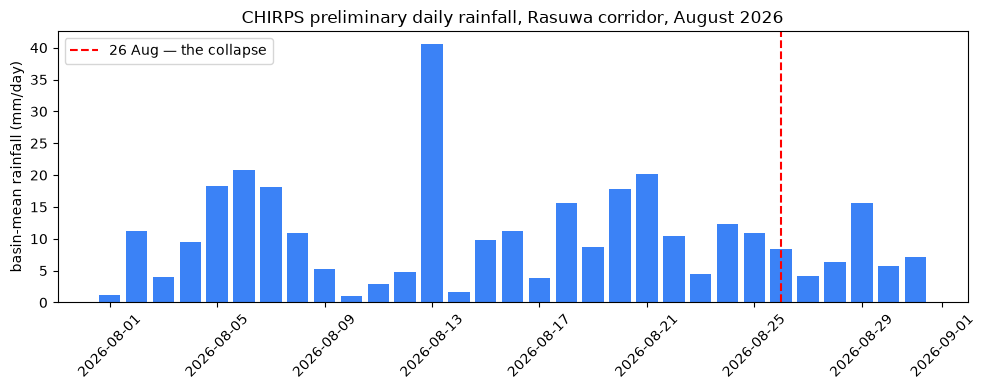

rainfall on 26 Aug 2026: 8.34 mm
August 2026 mean: 10.43 mm/day
26 Aug percentile within August 2026: 42th


In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(series.index, series.values, color="#3b82f6")
event_day = pd.Timestamp("2026-08-26")
ax.axvline(event_day, color="red", ls="--", label="26 Aug — the collapse")
ax.set_ylabel("basin-mean rainfall (mm/day)")
ax.set_title("CHIRPS preliminary daily rainfall, Rasuwa corridor, August 2026")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../dist/rainfall_august_2026.png", dpi=100)
plt.show()

event_value = series[event_day]
percentile = (series < event_value).mean() * 100
print(f"rainfall on 26 Aug 2026: {event_value:.2f} mm")
print(f"August 2026 mean: {series.mean():.2f} mm/day")
print(f"26 Aug percentile within August 2026: {percentile:.0f}th")

**26 August 2026: 8.34 mm, the 42nd percentile of that month — below the August
mean. Rainfall does not explain the event.**

Caveat, carried through to every rendering: this is the **preliminary** CHIRPS product.
The gauge-corrected final for August 2026 was not yet published at the time of this
analysis; values may revise.

## Monthly climatology, 2006–2026, for the seasonal percentile

In [3]:
monthly = {}
for f in sorted(glob.glob("../data/bronze/chirps/*.tif")):
    stem = Path(f).stem.replace("chirps-v2.0.", "")
    with rasterio.open(f) as ds:
        a = ds.read(1).astype(float)
        a = a[a >= 0]
        monthly[stem] = float(a.mean()) if a.size else float("nan")

m = pd.Series(monthly)
m.index = pd.to_datetime(m.index, format="%Y.%m")
august = m[m.index.month == 8]
print(f"August values across {len(august)} years: mean {august.mean():.1f} mm, "
      f"median {august.median():.1f} mm")
print(f"years covered: {august.index.year.min()}-{august.index.year.max()}")

August values across 20 years: mean 314.5 mm, median 294.8 mm
years covered: 2006-2025
